LoanForest is a Streamlit web application that predicts the risk of loan default using a Random Forest machine learning model. Users interact with the app via feature sliders to input loan and applicant details, receiving an instant prediction of default risk.

**Loading Necessary Libraries**

In [13]:
# Utilities and data manipulation libraries
import joblib
import pandas as pd
import numpy as np
import os

# SHAP library for model explainability
import shap

# Data visualization libraries
import plotly
import seaborn as sns
from matplotlib import pyplot as plt
from optuna.visualization import plot_optimization_history, plot_param_importances

# Machine learning libraries
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV

# Model evaluation libraries
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    make_scorer,
    precision_recall_curve,
) 

# Libraries for handling imbalance
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline

%matplotlib inline

**Loading Dataset**

In [14]:
# Loading the dataset
df = pd.read_csv("../data/loan_data.csv")

In [15]:
# Displaying the first few rows of the dataset
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [16]:
# Displays the columns names
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='str')

**Data Preview and Cleaning**

In [17]:
# Data Overview and Cleaning Function
def data_preview(data):
    """
    Provides a quick overview of the dataframe including:
      shape, 
      info, 
      description, 
      missing values
      duplicates.
    Args:
        df: The input dataframe.
    Returns:
        None
    """
    print("Dataframe Shape:", data.shape)
    print("\nDataframe Info:")
    print(data.info())
    print("\nMissing Values:")
    print(data.isnull().sum())
    print("\nNumber of Duplicates:") 
    print(data.duplicated().sum())
    print("\nCount of Values Not Fully Paid:")
    print(data['not.fully.paid'].value_counts())
    

# Calling the data preview function
data_preview(df)

Dataframe Shape: (9578, 14)

Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None

Missing Values:
credit.poli

**Exploratory Data Analysis (EDA)**

In [18]:
# Data Visualization Function
def data_visualization(data):
    """
    Visualizes the relationships between some key features and the target variable 
    'not.fully.paid' using various plots.
    Args:
        data: The input dataframe.
    Returns:
        None
    """
    # Set the style of the plots
    sns.set_style("whitegrid")
    # Setting up the figure and axes for multiple plots
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(29, 15))

    # Flatten the axes array for easy indexing
    axes = axes.flatten()
    
    # Plot the distribution of the target variable
    sns.countplot(x='not.fully.paid', 
                  data=data, 
                  ax=axes[0])
    axes[0].set_title('Distribution of Not Fully Paid')
    axes[0].set_xlabel('Not Fully Paid (0 = No, 1 = Yes)')
    axes[0].set_ylabel('Count')

    # Plot the relationship between 'fico' scores and 'not.fully.paid'
    sns.boxplot(x='not.fully.paid', 
                y='fico', 
                data=data, 
                ax=axes[1])
    axes[1].set_title('FICO Scores by Not Fully Paid Status')
    axes[1].set_xlabel('Not Fully Paid (0 = No, 1 = Yes)')
    axes[1].set_ylabel('FICO Score')

    # Plot the relationship between 'fico' scores and 'int.rate'
    sns.scatterplot(x='fico', 
                    y='int.rate', 
                    data=data, 
                    ax=axes[2],
                    alpha=0.5)
    axes[2].set_title('FICO Scores vs Interest Rate')
    axes[2].set_xlabel('FICO Score')
    axes[2].set_ylabel('Interest Rate')

    # Plot the relationship between 'purpose' and 'not.fully.paid'
    sns.countplot(x='purpose', 
                  hue='not.fully.paid', 
                  data=data,
                  ax=axes[3], 
                  palette='Set1')
    axes[3].set_title('Purpose vs Not Fully Paid')
    axes[3].set_xlabel('Purpose of Loan')
    axes[3].set_ylabel('Count')
    axes[3].legend(title='Not Fully Paid')

    # Computing the correlation matrix and visualizing it with a heatmap.
    corr = data.select_dtypes(include=['number']).corr()
    sns.heatmap(corr, 
                annot=True, 
                cmap='coolwarm', 
                linewidths=0.5, 
                ax=axes[4])
    axes[4].set_title('Correlation Heatmap')
    fig.savefig('./images/data_visualization.png')

    # Hide the last subplot (empty)
    axes[5].set_visible(False)

    fig.tight_layout()
    plt.show()  

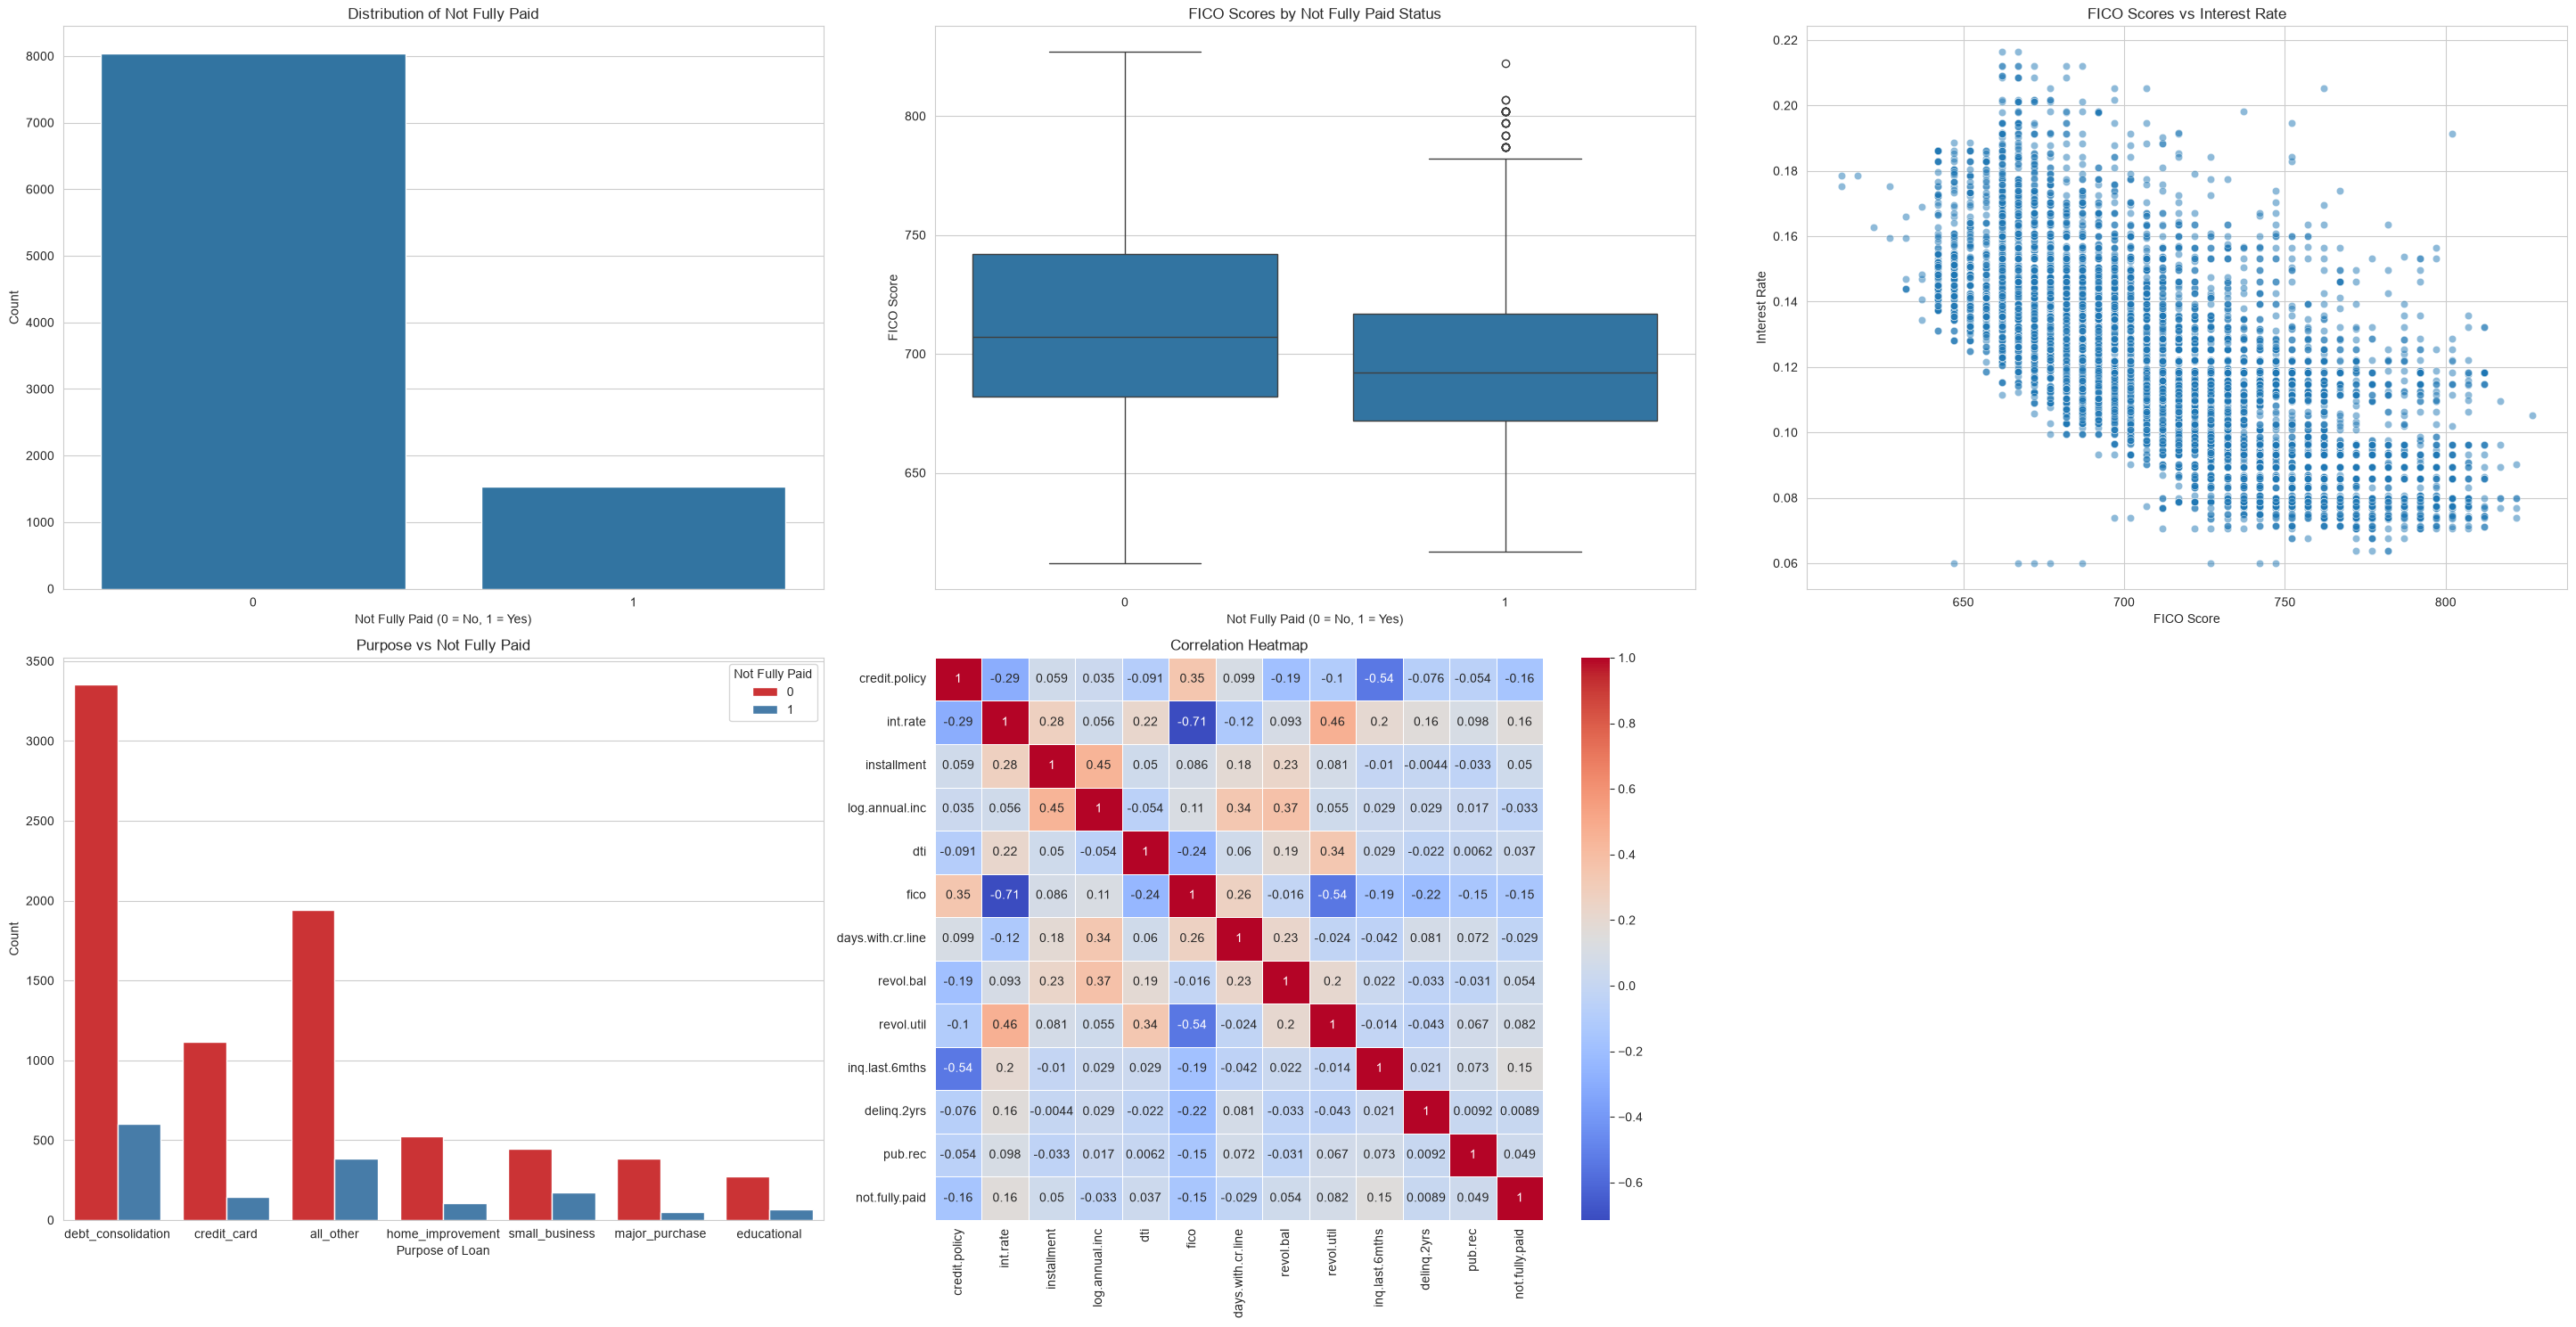

In [19]:
# Calling the data visualization function.
data_visualization(df)

**Feature Engineering**

In [20]:
# def engineer_features(data):

#     data = data.copy()

#     data["credit_income_ratio"] = (
#         data["loan_amnt"] /
#         (data["annual_inc"] + 1)
#     )

#     data["debt_income_ratio"] = (
#         data["dti"] /
#         (data["annual_inc"] + 1)
#     )

#     data["fico_mean"] = (
#         data["fico_range_low"] +
#         data["fico_range_high"]
#     ) / 2

#     return data

In [21]:
# Global variable for feature importance elsewhere in the notebook
X = df.drop(columns='not.fully.paid')
y = df['not.fully.paid']

# Function to split data into train/test sets, encode categorical variables, and scale features
def split_data(label, target, test_size=0.2, random_state=42):
    """
    This function splits the dataframe into training and testing sets.
    1. Splits the dataset into training and testing sets using an 80-20 ratio.
    
    Args:
        label (pd.DataFrame): The input dataframe to be split.
        target (pd.Series): The target variable.
        test_size (float): The proportion of the dataset to include in the test split.
        random_state (int): The seed used by the random number generator.
    Returns:
        X_train, X_test, y_train, y_test: Split datasets.
    """
    
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(label, target, test_size=test_size, 
                                                        stratify=target,
                                                        random_state=random_state)

    # Print the shapes of the split datasets
    print(
        f"X_train: {X_train.shape}, X_test: {X_test.shape}," 
        f"y_train: {y_train.shape}, y_test: {y_test.shape}"
        )
    
    return X_train, X_test, y_train, y_test

In [22]:
# Apply the split_data function to the preprocessed dataframe
X_train, X_test, y_train, y_test, = split_data(X, y)

X_train: (7662, 13), X_test: (1916, 13),y_train: (7662,), y_test: (1916,)


In [23]:
CATEGORICAL_COLS = ['purpose']
NUMERIC_COLS = [col for col in X.columns if col not in CATEGORICAL_COLS]

# Define the categorical transformer using TargetEncoder
categorical_transformer = Pipeline(steps=[
    ('target_encoder', TargetEncoder())
 ])

# Define the preprocessor using ColumnTransformer to apply the categorical transformer to the appropriate columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, CATEGORICAL_COLS)
        ],
    remainder='passthrough'
)

**Model Development.**

In [24]:
# Define pipeline with preprocessor, SMOTEENN, and RandomForestClassifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smoteenn', SMOTEENN(random_state=42, smote=SMOTE(), enn=EditedNearestNeighbours())),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define the cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# Define the function to optimize hyperparameters using Optuna
def best_hyperparameters(trial):
    # Match the exact pipeline parameter names directly in Optuna
    rf_params = {
        'rf__n_estimators': trial.suggest_int('rf__n_estimators', 200, 1200),
        'rf__max_depth': trial.suggest_int('rf__max_depth', 5, 40),
        'rf__min_samples_split': trial.suggest_int('rf__min_samples_split', 2, 30),
        'rf__min_samples_leaf': trial.suggest_int('rf__min_samples_leaf', 1, 20),
        'rf__class_weight': trial.suggest_categorical('rf__class_weight', ['balanced', 'balanced_subsample'])
    }
    
    # Apply parameters directly to the pipeline
    pipeline.set_params(**rf_params)
    
    scorer = make_scorer(balanced_accuracy_score)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1)
    
    return scores.mean()

# Create an Optuna study and optimize the hyperparameters
study = optuna.create_study(direction='maximize', 
                            sampler=TPESampler(seed=42),
                            study_name='loan_default_rf_v1'
                            )
study.optimize(best_hyperparameters, n_trials=25)

# Get the best hyperparameters
best_params = study.best_params
print("Best Hyperparameters:", best_params)

[I 2026-06-29 19:37:22,207] A new study created in memory with name: loan_default_rf_v1
[I 2026-06-29 19:38:34,375] Trial 0 finished with value: 0.5379897208953413 and parameters: {'rf__n_estimators': 574, 'rf__max_depth': 39, 'rf__min_samples_split': 23, 'rf__min_samples_leaf': 12, 'rf__class_weight': 'balanced'}. Best is trial 0 with value: 0.5379897208953413.
[I 2026-06-29 19:39:01,185] Trial 1 finished with value: 0.5440828878783356 and parameters: {'rf__n_estimators': 258, 'rf__max_depth': 36, 'rf__min_samples_split': 19, 'rf__min_samples_leaf': 15, 'rf__class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.5440828878783356.
[I 2026-06-29 19:40:41,873] Trial 2 finished with value: 0.5353902572456579 and parameters: {'rf__n_estimators': 1033, 'rf__max_depth': 12, 'rf__min_samples_split': 7, 'rf__min_samples_leaf': 4, 'rf__class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.5440828878783356.
[I 2026-06-29 19:41:48,455] Trial 3 finished with value: 0.528

Best Hyperparameters: {'rf__n_estimators': 460, 'rf__max_depth': 5, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 19, 'rf__class_weight': 'balanced'}


In [25]:
# Plot optimization history
fig_history = plot_optimization_history(study)
fig_history.show()

# Plot parameter importances
fig_importances = plot_param_importances(study)
fig_importances.show()

In [26]:
# Define a function to train the final calibrated pipeline.
def train_calibrated_pipeline(X_train, y_train, X_test, y_test, preprocessor, clean_params):
    """
    Builds the final pipeline, performs 5-fold cross-validated calibration,
    and finds the optimal F1-score classification threshold.
    
    Args:
    X_train, y_train : Features and targets for training
    X_test, y_test   : Features and targets for testing
    preprocessor     : Fitted or unfitted ColumnTransformer instance
    clean_params     : Dict of tuned hyperparameters for RandomForestClassifier (without prefixes)
    
    Returns:
        'model': Fitted CalibratedClassifierCV object
        'probabilities': Predicted test probabilities
        'predictions': Predicted test labels based on optimal threshold
        'best_threshold': The optimized F1-score threshold
        'f1_scores': Calculated F1 scores across thresholds
    """
    # Build the final pipeline.
    final_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smoteenn', SMOTEENN(random_state=42, smote=SMOTE(), enn=EditedNearestNeighbours())),
        ('rf', RandomForestClassifier(**clean_params, random_state=42, n_jobs=-1))
    ])
    
    # Cross-validated using calibration (cv=5 builds internally un-biased folds)
    calibrated_rf = CalibratedClassifierCV(
        estimator=final_pipeline,
        method='isotonic',
        cv=5
    )
    
    # Fit the calibrated model architecture
    print("Fitting calibrated pipeline across CV folds...")
    calibrated_rf.fit(X_train, y_train)
    
    # Predict probabilities on test set
    y_prob = calibrated_rf.predict_proba(X_test)[:, 1]
    
    # Optimize the decision threshold using the Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    # Apply optimal threshold to derive definitive predictions
    y_pred = (y_prob >= best_threshold).astype(int)
    
    return {
        'model': calibrated_rf,
        'probabilities': y_prob,
        'predictions': y_pred,
        'best_threshold': best_threshold,
        'f1_scores': f1_scores
    }

In [27]:
# Assuming your Optuna study has finished running:
best_params = study.best_params
clean_params = {key.replace('rf__', ''): value for key, value in best_params.items()}

# Execute the function
results = train_calibrated_pipeline(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    preprocessor=preprocessor, 
    clean_params=clean_params
)

# Extract your outputs cleanly
final_model = results['model']
y_pred = results['predictions']
optimized_threshold = results['best_threshold']
y_prob = results['probabilities']

print(f"Optimal F1 Threshold found: {optimized_threshold:.4f}")

Fitting calibrated pipeline across CV folds...
Optimal F1 Threshold found: 0.1670


In [28]:
# Function to display classification report and confusion matrix
def model_result(y_true, y_hat):
    """
    Displays the confusion matrix and classification report for the given true and predicted labels.
    Args:
        y_true: The true labels.
        y_hat: The predicted labels.
    Return:
        classification_report: A text summary of the precision, recall, F1 score, and support for each class.
        roc_auc_score: The area under the receiver operating characteristic curve.
        balanced_accuracy_score: The balanced accuracy score.
    """
    # Compute the confusion matrix.
    cm = confusion_matrix(y_true, y_hat)

    # Visualize using heatmap.
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, cmap='coolwarm', linewidths=0.5,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    
    plt.title('Confusion Matrix')
    plt.xlabel("Predicted Labels.")
    plt.ylabel("Actual Labels.")
    plt.tight_layout()
    plt.savefig('./images/confusion_matrix.png')
    plt.show()

    class_report = classification_report(y_true, y_hat)
    roc_auc = roc_auc_score(y_true, y_prob)
    balanced_acc = balanced_accuracy_score(y_true, y_hat)

    print(f"Classification Report:\n{class_report}")
    print(f"ROC AUC: {roc_auc}")
    print(f"Balanced Accuracy: {balanced_acc}")


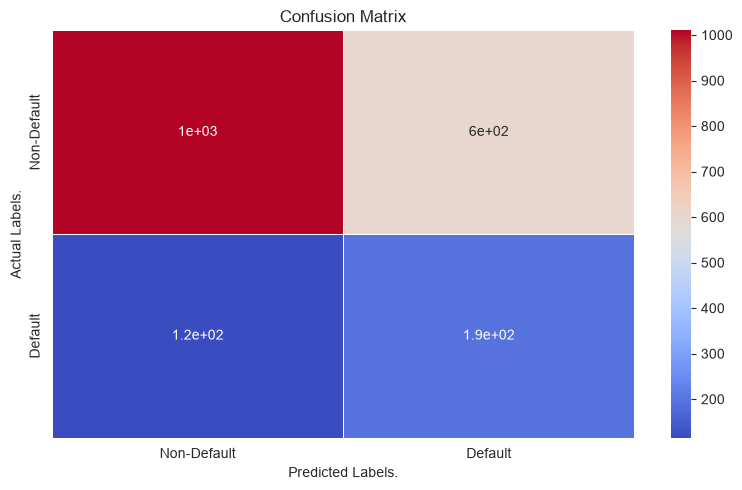

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.63      0.74      1609
           1       0.24      0.63      0.35       307

    accuracy                           0.63      1916
   macro avg       0.57      0.63      0.54      1916
weighted avg       0.79      0.63      0.68      1916

ROC AUC: 0.6669315313090252
Balanced Accuracy: 0.6265631231488997


In [29]:
# Initialize the model evaluation function
model_result(y_test, y_pred)

In [30]:
# Function to explain a single applicant's prediction using SHAP values
def explain_single_applicant(model, X_explain, row_index, columns_names,
                              top_n=10, save_path=None):
    """
    Generates a per-applicant SHAP explanation with waterfall plot.

    Args:
        model: The trained model (RandomForestClassifier or Pipeline).
        X_explain: The DataFrame containing the features for explanation.
        row_index: The index of the applicant in X_explain to explain.
        columns_names: List of feature names corresponding to the columns in X_explain.
        top_n: The number of top features to display in the waterfall plot.
        save_path: Optional path to save the waterfall plot. If None, the plot will be displayed instead of saved.
    Returns:
        explanation_df: DataFrame containing feature names, values, and SHAP contributions.
        base_value: The baseline prediction value (average predicted default probability).
        predicted_value: The predicted value for the specific applicant.
    """
    # Extract the tree model whether it's bare or inside a Pipeline
    if hasattr(model, 'feature_importances_'):
        tree_model = model
    elif hasattr(model, 'named_steps') and 'rf' in model.named_steps:
        tree_model = model.named_steps['rf']
    else:
        raise ValueError("Model does not expose a tree-based estimator named 'rf'.")

    # Keep row as a DataFrame to preserve structure
    row = X_explain.iloc[[row_index]]

    try:
        # Use check_additivity=False if you encounter slight floating-point mismatches
        explainer = shap.TreeExplainer(tree_model, model_output="probability", data=X_explain)
        explanation = explainer(row)
    except Exception as e:
        print(f"Error occurred while calculating SHAP values for this applicant: {e}")
        return None, None, None

    # Handle multi-class / binary classification output shapes safely
    # If explanation has 3 dimensions (row, feature, class), isolate class 1 (default)
    if len(explanation.shape) == 3:
        exp_individual = explanation[0, :, 1]
    else:
        exp_individual = explanation[0]

    # Explicitly assign feature names to ensure alignment
    exp_individual.feature_names = list(columns_names)

    base_value = exp_individual.base_values
    contributions = exp_individual.values
    predicted_value = base_value + contributions.sum()

    # Create the summary DataFrame
    explanation_df = pd.DataFrame({
        'Feature Name': columns_names,
        'Feature Value': row.iloc[0].values,
        'SHAP Contribution': contributions
    })
    explanation_df['Abs Contribution'] = explanation_df['SHAP Contribution'].abs()
    explanation_df = explanation_df.sort_values(by='Abs Contribution', ascending=False)
    explanation_df = explanation_df.drop(columns='Abs Contribution').reset_index(drop=True)

    # Waterfall plot generation
    try:
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp_individual, max_display=top_n, show=False)
        if save_path:
            plt.tight_layout()
            plt.savefig(save_path, dpi=80, bbox_inches='tight')
            plt.close()
            print(f"Waterfall plot saved to {save_path}")
        else:
            plt.show()
    except Exception as e:
        print(f"Error occurred while plotting waterfall: {e}")

    print(f"Baseline (average predicted default probability): {base_value:.3f}")
    print(f"This applicant's predicted default probability:   {predicted_value:.3f}")

    return explanation_df, base_value, predicted_value

In [31]:
# Preprocess the test data
def get_fitted_preprocessor(calibrated_model):
    """
    Safely extracts the already-fitted preprocessor from a CalibratedClassifierCV.
    Raises if the structure doesn't match expectations.
    """
    try:
        fitted_estimator = calibrated_model.calibrated_classifiers_[0].estimator
        return fitted_estimator.named_steps['preprocessor']
    except (AttributeError, KeyError, IndexError) as e:
        raise ValueError(f"Could not extract preprocessor from model: {e}")

pre_processor = get_fitted_preprocessor(final_model)
X_test_processed = pre_processor.transform(X_test)   # transform only — no fit
X_test_processed_df = pd.DataFrame(X_test_processed, columns=X.columns)

In [32]:
# Initialize the feature importance function
explanation_df, base_value, predicted_value = explain_single_applicant(
    model=final_model.calibrated_classifiers_[0].estimator.named_steps['rf'],
    X_explain=X_test_processed_df,
    row_index=0,
    columns_names=X.columns,
    top_n=10,
    save_path='./images/applicant_explanation.png'
)
print(explanation_df)

Background dataset has 1916 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1916 when initializing the masker.


Waterfall plot saved to ./images/applicant_explanation.png
Baseline (average predicted default probability): 0.385
This applicant's predicted default probability:   0.477
         Feature Name  Feature Value  SHAP Contribution
0             purpose       0.000000           0.121213
1      inq.last.6mths       0.000000          -0.087538
2            int.rate       0.155100           0.024399
3         installment     418.990000           0.019188
4          revol.util      70.100000           0.012690
5                 dti      15.380000           0.011208
6       credit.policy       0.153876          -0.004467
7   days.with.cr.line    1860.000000          -0.004065
8      log.annual.inc      11.034890           0.001868
9                fico     647.000000          -0.001458
10            pub.rec       0.000000          -0.000671
11          revol.bal   11214.000000          -0.000552
12        delinq.2yrs       0.000000          -0.000342


In [33]:
def plot_local_and_global_shap(model, X_explain, row_index, columns_names, top_n=10):
    """
    Plots a single applicant's waterfall plot side-by-side with the 
    overall dataset beeswarm summary plot.
    """
    # 1. Extract the tree estimator
    if hasattr(model, 'feature_importances_'):
        tree_model = model
    elif hasattr(model, 'named_steps') and 'rf' in model.named_steps:
        tree_model = model.named_steps['rf']
    else:
        raise ValueError("Model does not expose a tree-based estimator named 'rf'.")

    # 2. Compute explanations for both the single row and the entire pool
    explainer = shap.TreeExplainer(tree_model, model_output="probability", data=X_explain)
    
    # Calculate for all records (for Beeswarm) and single record (for Waterfall)
    all_explanations = explainer(X_explain)
    single_explanation = all_explanations[[row_index]]

    # 3. Handle multi-class dimensions for Random Forest output shape
    if len(all_explanations.shape) == 3:
        global_exp = all_explanations[:, :, 1]
        local_exp = single_explanation[0, :, 1]
    else:
        global_exp = all_explanations
        local_exp = single_explanation[0]

    # Assign feature names to the explanation objects
    global_exp.feature_names = list(columns_names)
    local_exp.feature_names = list(columns_names)

    # 4. Initialize matplotlib figure side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # Render Waterfall Plot on the Left
    plt.sca(axes[0])
    axes[0].set_title(f"Local Explanation: Applicant Row {row_index}", fontsize=14, pad=20)
    shap.plots.waterfall(local_exp, max_display=top_n, show=False)

    # Render Beeswarm Plot on the Right
    plt.sca(axes[1])
    axes[1].set_title("Global Explanation: Overall Feature Impact", fontsize=14, pad=20)
    shap.plots.beeswarm(global_exp, max_display=top_n, show=False)

    plt.subplots_adjust(
        left=0.15, right=0.90, top=0.85, bottom=0.15, wspace=0.45
    )

    fig.savefig('./images/local_global_shap.png', dpi=80, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

Background dataset has 1916 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1916 when initializing the masker.
100%|===================| 3829/3832 [02:15<00:00]        

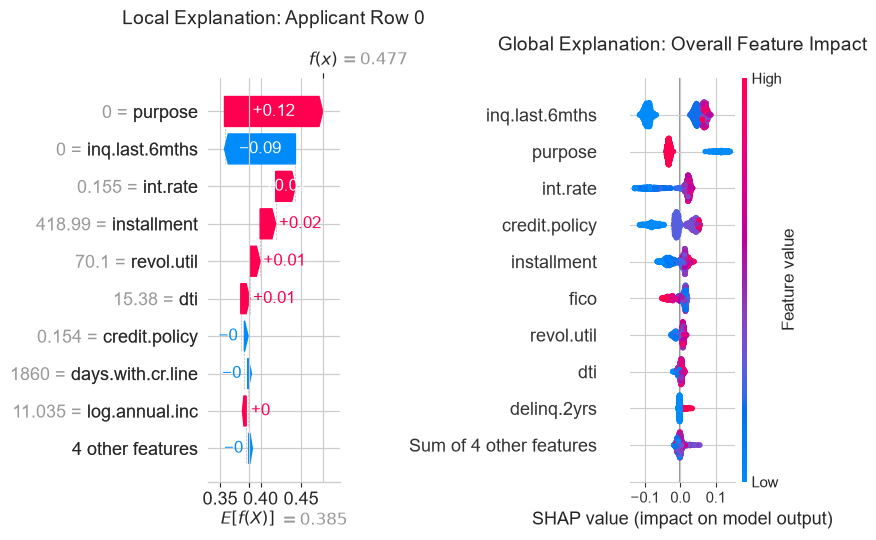

In [34]:
# Initialize the combined SHAP plotting function
plot_local_and_global_shap(
    model=final_model.calibrated_classifiers_[0].estimator.named_steps['rf'],
    X_explain=X_test_processed_df,
    row_index=0,
    columns_names=X.columns,
    top_n=10
)

In [35]:
# Save the trained model to disk
def save_model(model, threshold, filename):
    """
    Saves the trained model to disk using joblib.
    Args:
        model: The trained model to be saved.
        threshold: The optimal threshold for the model.
        filename: The name of the file where the model will be saved.
    Returns:
        None
    """
    try:
        # Check if the directory exists, if not, create it
        dir_path = os.path.dirname(filename)
        if dir_path and not os.path.exists(dir_path):
            os.makedirs(dir_path)
            print(f"Directory '{dir_path}' created.")

        # Save the model to disk
        joblib.dump({'model': model, 'threshold': threshold}, filename)
        print(f"Model successfully saved to {filename}")

    except FileNotFoundError as e:
        print(f"Error: File not found when saving model: {e}")

    except PermissionError as e:
        print(f"Error: Permission denied when saving model: {e}")

    except Exception as e:
        print(f"An unexpected error occurred while saving the model: {e}")

In [36]:
# Save the trained model to disk
save_model(final_model, optimized_threshold, './src/final_rf_model.pkl')

Model successfully saved to ./src/final_rf_model.pkl


In [37]:
# Function to load the model make predictions.
def load_and_predict(data):
    """
    Loads a trained model makes predictions on new data and inverse the transform label.
        1. Loads the trained model from disk.
        2. Makes predictions on the provided clean dataframe.
    Args:
        clean_df (pd.DataFrame): The preprocessed test dataframe.
    Returns:
        np.ndarray: The predicted labels in their original categorical form.
    """
    try:
        print("Loading the trained model...")
        # Load the trained model
        artifact = joblib.load("notebooks\\src\\final_rf_model.pkl")
        model = artifact['model']
        threshold = artifact['threshold']
        print("Model loaded successfully.")
        # Make predictions
        predictions = (model.predict_proba(data)[:, 1] > threshold).astype(int)
        print("Predictions made successfully.")

    except FileNotFoundError:
        print("Error: The model file was not found. Please ensure the model has been trained and saved correctly.")
        return None
    except KeyError as e:
        print(f"Prediction Error. Feature mismatch likely. {e}")
        return None
    except Exception as e:  
        print(f"An error occurred while loading the model: {e}")
        return None

    return predictions